# Workshop 1 — Perturbation and SHAP

**Goal:** understand how baselines, interactions, and targets change an attribution.

**Flow:** two-feature example → image occlusion → image SHAP.

**RTG 2767 version:** complete solution.


## Presenter path — about 35 minutes

1. **Say:** perturbation asks how a score changes when information is replaced.
2. **Run:** the two-feature example, then the clean/watermarked image.
3. **Compare:** black versus blurred occlusion baselines.
4. **Finish:** compare SHAP for `carton` and `French horn`.

Teaching warning: an attribution depends on the target and on what “missing”
means. Do not describe a red region as causal without an intervention.


## Run once — environment setup

Run the next cell; **do not present it**. In Google Colab it clones the small
public workshop repository and installs the additional dependencies. The first
run also downloads pretrained model weights and Imagenette.


In [3]:
import subprocess
import sys
from pathlib import Path

PUBLIC_REPOSITORY_URL = "https://github.com/erfanhatefi/rtg2767-xai-workshop.git"
PUBLIC_REPOSITORY_REF = "main"

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    REPOSITORY_ROOT = Path("/content/rtg2767-xai-workshop")
    if not (REPOSITORY_ROOT / "utils").is_dir():
        subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "--branch",
                PUBLIC_REPOSITORY_REF,
                PUBLIC_REPOSITORY_URL,
                str(REPOSITORY_ROOT),
            ],
            check=True,
        )
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "-r",
            str(REPOSITORY_ROOT / "requirements.txt"),
        ],
        check=True,
    )
else:
    candidates = (Path.cwd(), *Path.cwd().parents)
    REPOSITORY_ROOT = next(
        path for path in candidates if (path / "utils").is_dir()
    )

sys.path.insert(0, str(REPOSITORY_ROOT))
WORKSHOP_DATA_ROOT = REPOSITORY_ROOT / "workshop_data"
print("Setup complete.")

Setup complete.


## Before attributing: three labels that are easy to confuse

- **Dataset label:** what the dataset says is present in the image.
- **Top-1 prediction:** the output with the largest score for this input.
- **Explanation target:** the particular output score whose heatmap we request.

An ImageNet model has 1,000 output scores, indexed from 0 to 999. A heatmap is
always conditional on one selected output; it need not be the top-1 prediction.
In these notebooks we resolve targets by readable names and print the resulting
index: `carton` is index **478**, `French horn` is index **566**, and index **0**
is `tench`. The `carton` class means a cardboard carton/box. ImageNet-W adds a
watermark intended to raise that output—it does not claim that a carton is
actually visible in the photograph.


In [4]:
import math
import time
from functools import partial
from itertools import permutations

import numpy as np
import torch
import torchvision
from torchvision.transforms.functional import gaussian_blur

from utils import (
    load_pretrained_resnet18,
    load_watermark_example,
    normalize_imagenet,
    occlusion,
    plot_bwr_attributions,
    predict_image_logits,
    resolve_imagenet_class_index,
    show_image_grid,
)

SEED = 7
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch {torch.__version__} | Torchvision {torchvision.__version__} | {device}")

PyTorch 2.7.1+cu128 | Torchvision 0.22.1+cu128 | cuda


---
## 1. Why leave-one-out attribution can over-count interactions

Consider the small non-tabular game

$$
f(x_1,x_2)=x_1x_2,
\qquad x=(1,1),
\qquad b=(0,0).
$$

Removing either feature from the complete input reduces the score from 1 to 0. Naive ablation therefore assigns the complete change to both features.

In [5]:
def product_model(input_values):
    """Return the scalar interaction f(x_1, x_2) = x_1 x_2."""
    return input_values[0] * input_values[1]


def leave_one_out(model, input_values, baseline_values):
    """Measure the score drop from replacing one feature at a time."""
    # Evaluate the complete input once before removing any feature.
    full_score = model(input_values)
    attributions = torch.zeros_like(input_values, dtype=torch.float32)

    for feature_index in range(input_values.numel()):
        # Every iteration starts from the same complete input.
        perturbed_input = input_values.clone()

        # Only the selected feature is replaced by its reference value.
        perturbed_input[feature_index] = baseline_values[feature_index]
        perturbed_score = model(perturbed_input)

        # Positive attribution means removing this feature lowered the score.
        attributions[feature_index] = full_score - perturbed_score

    return attributions


toy_input = torch.tensor([1.0, 1.0])
toy_baseline = torch.tensor([0.0, 0.0])
ablation_values = leave_one_out(product_model, toy_input, toy_baseline)
full_score_change = product_model(toy_input) - product_model(toy_baseline)

print(f"Total score change      : {full_score_change.item():.1f}")
print(f"Leave-one-out values    : {ablation_values.tolist()}")
print(f"Sum of ablation values  : {ablation_values.sum().item():.1f}")

Total score change      : 1.0
Leave-one-out values    : [1.0, 1.0]
Sum of ablation values  : 2.0


Shapley values average each feature's marginal contribution over every ordering:

$$
\phi_i
=\frac{1}{M!}\sum_{\pi}
\left[v(P_i^\pi\cup\{i\})-v(P_i^\pi)\right].
$$

The factorial implementation below is intentionally transparent and intentionally restricted to tiny examples.

In [6]:
def subset_score(model, inputs, baseline, present):
    """Evaluate a feature subset; absent features take baseline values."""
    mixed_input = baseline.clone()
    mixed_input[list(present)] = inputs[list(present)]
    return model(mixed_input)


def shapley(model, inputs, baseline):
    """Average each feature's contribution over all arrival orders."""
    values = torch.zeros_like(inputs)
    features = tuple(range(inputs.numel()))

    for order in permutations(features):
        present = []
        previous_score = subset_score(model, inputs, baseline, present)
        for feature in order:
            present.append(feature)
            current_score = subset_score(model, inputs, baseline, present)
            values[feature] += current_score - previous_score
            previous_score = current_score

    return values / math.factorial(len(features))


shapley_values = shapley(product_model, toy_input, toy_baseline)
score_change = product_model(toy_input) - product_model(toy_baseline)

print(f"Shapley values       : {shapley_values.tolist()}")
print(f"Sum / score change   : {shapley_values.sum():.1f} / {score_change:.1f}")
assert torch.allclose(shapley_values.sum(), score_change)

Shapley values       : [0.5, 0.5]
Sum / score change   : 1.0 / 1.0


**Checkpoint:** ablation asks what happens when a feature is removed from the complete input. Shapley asks what the feature adds on average across contexts.

The efficiency identity

$$
\sum_i\phi_i=f(x)-f(b)
$$

holds in the exact output space being explained. Do not silently switch between logits and probabilities.

---
## 2. Reveal a controlled Clever Hans example

We use one Imagenette French-horn photograph and the published ImageNet-W
watermark transform. For this particular image, the watermark strongly raises
the `carton` score while the top-1 prediction remains `French horn`.

This pair is a controlled intervention on one input—not evidence that every
watermark or every ImageNet model behaves identically. Pixels remain in display
space $[0,1]$ and are normalized only inside the model call.


100%|██████████| 342M/342M [00:18<00:00, 19.0MB/s] 


clean       prediction=French horn  p=99.94%  carton logit= -0.241
watermarked prediction=French horn  p=99.87%  carton logit= +4.016
Explanation targets: 'carton' (index 478) and 'French horn' (index 566)


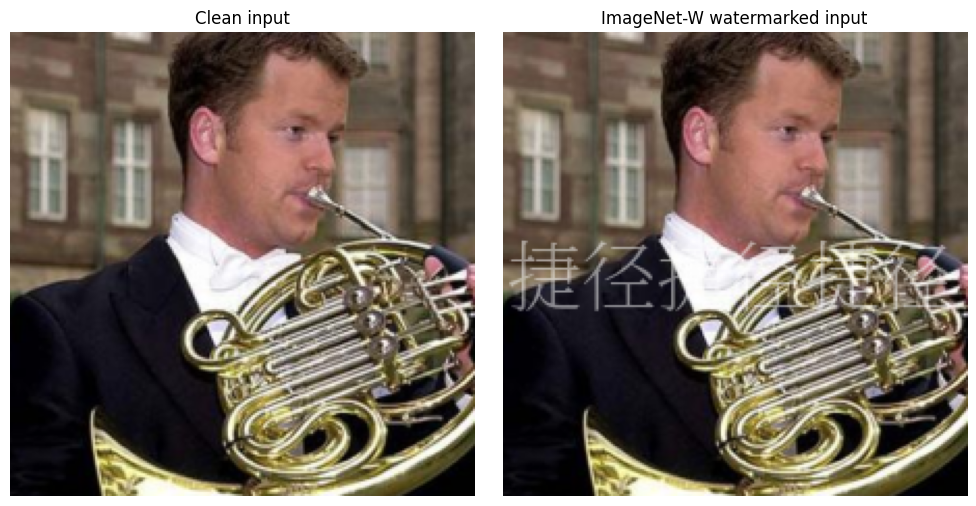

(<Figure size 1000x500 with 2 Axes>,
 array([<Axes: title={'center': 'Clean input'}>,
        <Axes: title={'center': 'ImageNet-W watermarked input'}>],
       dtype=object))

In [7]:
model, class_names = load_pretrained_resnet18(device)
image_path, clean_display_image, watermarked_display_image = load_watermark_example(
    WORKSHOP_DATA_ROOT,
    device,
)
display_image = watermarked_display_image

# Resolve readable names instead of asking learners to remember numeric indices.
CARTON_TARGET_NAME = "carton"
INTENDED_OBJECT_NAME = "French horn"
carton_target_index = resolve_imagenet_class_index(CARTON_TARGET_NAME)
intended_object_index = resolve_imagenet_class_index(INTENDED_OBJECT_NAME)
assert class_names[carton_target_index] == CARTON_TARGET_NAME
assert class_names[intended_object_index] == INTENDED_OBJECT_NAME

with torch.no_grad():
    # Normalization belongs at the model boundary; plots retain visible [0, 1] pixels.
    clean_logits = model(normalize_imagenet(clean_display_image))[0]
    watermarked_logits = model(normalize_imagenet(watermarked_display_image))[0]

for label, logits in [
    ("clean", clean_logits),
    ("watermarked", watermarked_logits),
]:
    probabilities = logits.softmax(dim=0)
    predicted_index = int(logits.argmax())
    print(
        f"{label:11s} prediction={class_names[predicted_index]:12s} "
        f"p={probabilities[predicted_index]:6.2%}  "
        f"carton logit={logits[carton_target_index]:+7.3f}"
    )

print(
    f"Explanation targets: {CARTON_TARGET_NAME!r} (index {carton_target_index}) "
    f"and {INTENDED_OBJECT_NAME!r} (index {intended_object_index})"
)

show_image_grid(
    [clean_display_image, watermarked_display_image],
    ["Clean input", "ImageNet-W watermarked input"],
)

---
## 3. Fast image occlusion

`occlusion(model, image, target, baseline, patch_size)` replaces one square
region at a time and measures the target-score change. The function derives
`stride = patch_size // 2`, so neighboring patches overlap by 50%. Overlap makes
the final map less blocky, while the implementation also shifts the last patch
to cover every border pixel.

We compare two baselines because “remove this region” has no unique visual
meaning. Patch size is also a scientific resolution choice: smaller patches
localize more precisely but require more model evaluations.


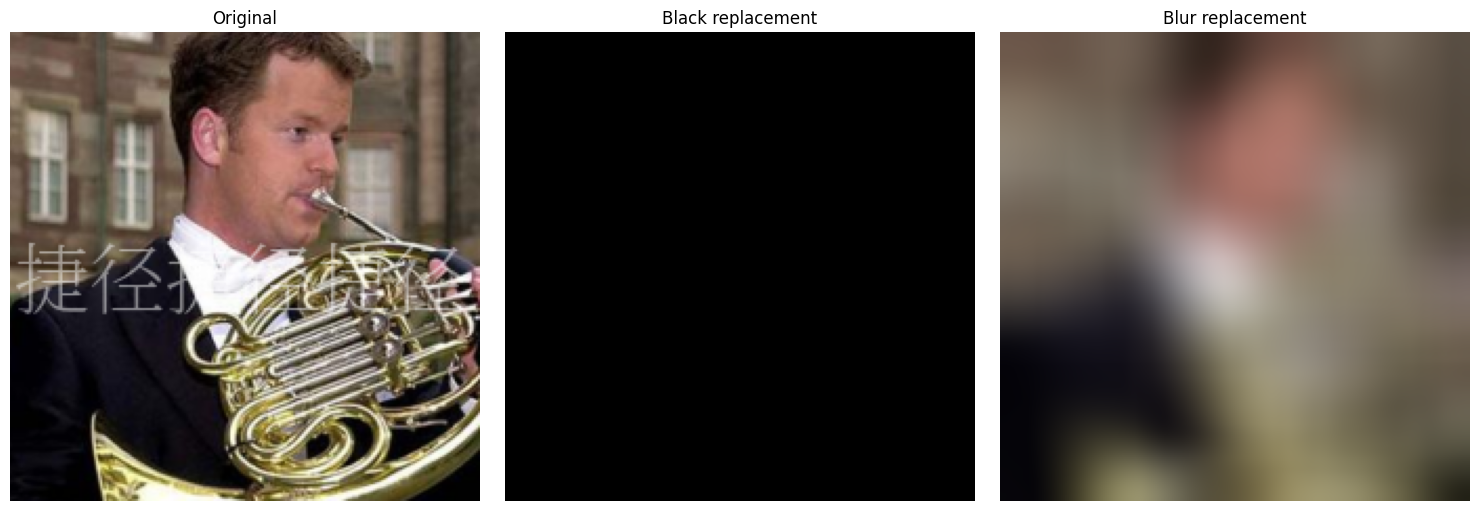

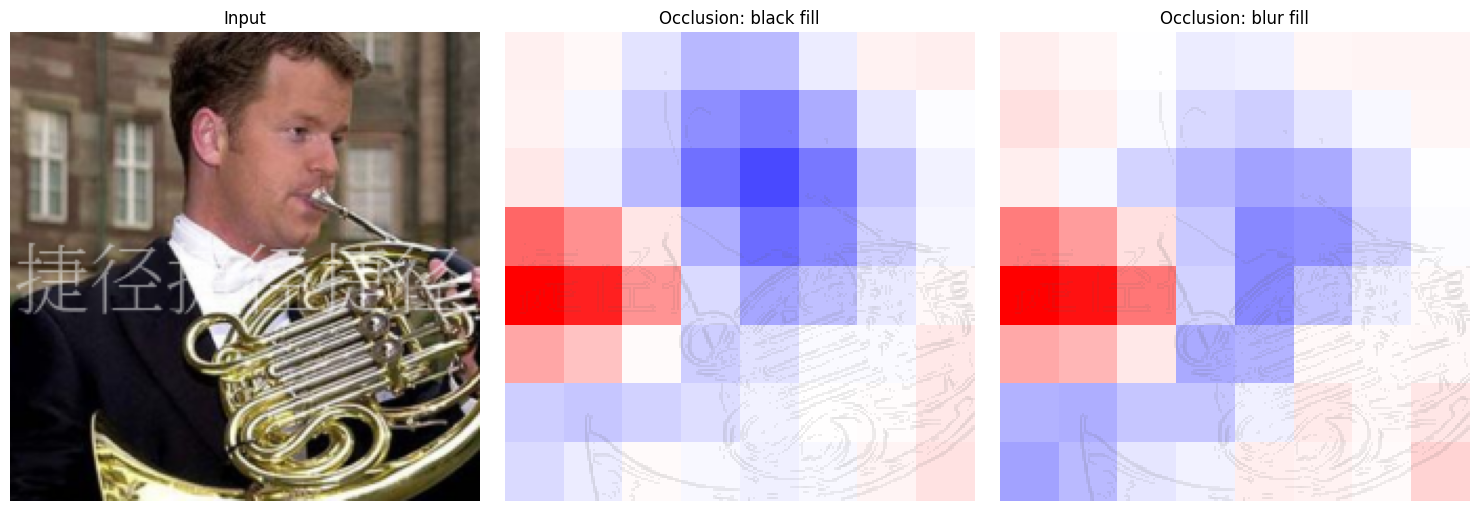

Target: 'carton'; logit=4.016
Two occlusion maps: 0.01 seconds


In [8]:
# A baseline defines the pixels used to replace an occluded region.
black_baseline = torch.zeros_like(display_image)
blurred_baseline = gaussian_blur(
    display_image,
    kernel_size=[51, 51],
    sigma=[18.0, 18.0],
)
show_image_grid(
    [display_image, black_baseline, blurred_baseline],
    ["Original", "Black replacement", "Blur replacement"],
)

# Each 56×56 patch overlaps its neighbors by 50%; stride is inferred as 28.
PATCH_SIZE = 56
occlusion_start = time.perf_counter()
black_occlusion, target_logit = occlusion(
    model,
    display_image,
    carton_target_index,
    black_baseline,
    patch_size=PATCH_SIZE,
)
blur_occlusion, _ = occlusion(
    model,
    display_image,
    carton_target_index,
    blurred_baseline,
    patch_size=PATCH_SIZE,
)
occlusion_seconds = time.perf_counter() - occlusion_start

# q sets the symmetric color limit to the 99th percentile of |attribution|.
plot_bwr_attributions(
    display_image,
    [black_occlusion, blur_occlusion],
    ["Occlusion: black fill", "Occlusion: blur fill"],
    q=99,
)
print(f"Target: {class_names[carton_target_index]!r}; logit={target_logit:.3f}")
print(f"Two occlusion maps: {occlusion_seconds:.2f} seconds")

**Heatmap convention:** blue is negative evidence under the perturbation, white is zero, and red is positive evidence. Each map is normalized independently, so color intensity cannot be compared numerically across maps.

**Interpretation:** differences between black and blur maps show sensitivity to missing-region semantics. Coarse blocks reflect the deliberately small evaluation budget, not precise object boundaries.

---
## 4. Fast image SHAP

### What does the Partition algorithm do?

Exact pixel Shapley values would require evaluating exponentially many subsets
of pixels. Partition SHAP first organizes image features into a **hierarchical
tree of neighboring regions**. It then recursively compares coalitions along
that tree instead of treating every possible pixel subset independently.

The returned values are hierarchical **Owen values**: credit is shared while
respecting the region tree. With a balanced tree, exact Partition SHAP is
quadratic rather than exponential in the number of input features. Our budget
of 64 evaluations stops much earlier, so this is deliberately a coarse live
demonstration.

For this example:

- **input layout:** SHAP receives NumPy images as `[batch, height, width, channels]`;
- **missing region:** `blur(32,32)` replaces a hidden region with blurred pixels;
- **explained outputs:** the pre-softmax `carton` and `French horn` logits;
- **evaluation budget:** at most 64 masked image evaluations;
- **batch size:** how many masked images run together; it changes speed and
  memory use, not the definition of the attribution.


In [9]:
try:
    import cv2
    import shap
except ImportError as error:
    raise ImportError(
        "Run `%pip install shap==0.49.1 "
        "opencv-python-headless==4.11.0.86` and restart the kernel."
    ) from error

# PyTorch uses NCHW: [batch, channels, height, width].
# SHAP's image interface uses NHWC: [batch, height, width, channels].
shap_images = display_image.detach().cpu().permute(0, 2, 3, 1).numpy()

# This wrapper accepts SHAP's NumPy images and returns one logit per class.
shap_model = partial(
    predict_image_logits,
    model=model,
    model_device=device,
)

# "blur(32,32)" defines what a hidden image region looks like.
image_masker = shap.maskers.Image("blur(32,32)", shap_images[0].shape)
image_explainer = shap.Explainer(
    shap_model,
    image_masker,
    output_names=class_names,
    algorithm="partition",
)

# Explain two named outputs to demonstrate that heatmaps are target-specific.
explained_class_indices = [carton_target_index, intended_object_index]

# Maximum number of masked image variants evaluated by Partition SHAP.
MAX_MODEL_EVALUATIONS = 64

# More images per batch are faster but consume more GPU/CPU memory.
MASKED_IMAGES_PER_BATCH = 64 if device.type == "cuda" else 16

print(f"SHAP {shap.__version__}; OpenCV {cv2.__version__}")
print("Explained outputs:", [class_names[i] for i in explained_class_indices])

SHAP 0.49.1; OpenCV 4.11.0
Explained outputs: ['carton', 'French horn']


Image SHAP: 1.81 seconds
Maximum local-additivity error: 3.51e-03


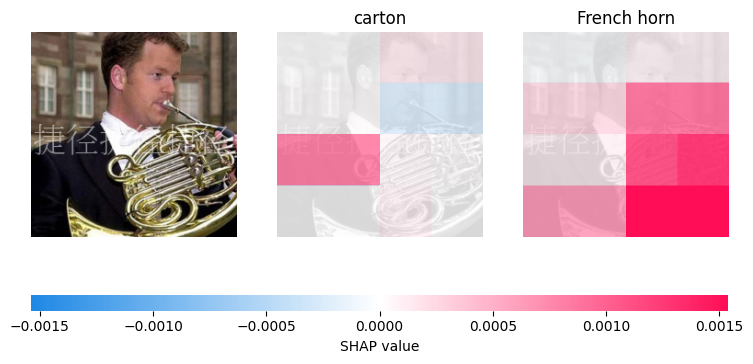

In [10]:
shap_start = time.perf_counter()
image_shap_values = image_explainer(
    shap_images,
    max_evals=MAX_MODEL_EVALUATIONS,
    batch_size=MASKED_IMAGES_PER_BATCH,
    outputs=explained_class_indices,
)
shap_seconds = time.perf_counter() - shap_start

# Partition SHAP should satisfy local accuracy:
# baseline output + all attributions ≈ the model output for this image.
reconstructed_logits = image_shap_values.base_values + image_shap_values.values.sum(
    axis=(1, 2, 3)
)
model_logits = shap_model(shap_images)[:, explained_class_indices]
max_additivity_error = np.abs(reconstructed_logits - model_logits).max()

print(f"Image SHAP: {shap_seconds:.2f} seconds")
print(f"Maximum local-additivity error: {max_additivity_error:.2e}")
assert np.allclose(reconstructed_logits, model_logits, atol=1e-2)
shap.image_plot(image_shap_values)

**Interpret carefully**

- Red regions raise the displayed class logit relative to the blur game; blue regions lower it.
- Compare the `carton` map with the French-horn map; both are target-specific. Inspect its score before describing the result.
- The 64-evaluation result is intentionally coarse. Use approximately 300–500 evaluations as a starting point for a more detailed exploratory run, then check stability rather than trusting one map.
- A visually pleasing explanation is not evidence of faithfulness.

## Take-home checklist

Always report the model/checkpoint, target and output space, feature grouping, baseline or masker, evaluation budget, preprocessing, and random seed.

### References

- Lundberg & Lee (2017), [A Unified Approach to Interpreting Model Predictions](https://papers.nips.cc/paper/7062-a-unified-approach-to-interpreting-model-predictions)
- Zeiler & Fergus (2014), [Visualizing and Understanding Convolutional Networks](https://arxiv.org/abs/1311.2901)
- Fong & Vedaldi (2017), [Meaningful Perturbation](https://openaccess.thecvf.com/content_iccv_2017/html/Fong_Interpretable_Explanations_of_ICCV_2017_paper.html)
- [SHAP image Partition explainer example](https://shap.readthedocs.io/en/latest/example_notebooks/image_examples/image_classification/Explain%20ResNet50%20using%20the%20Partition%20explainer.html)

The strongest validation is already available: remove the watermark and verify
that the `carton` logit collapses. The heatmaps suggest *where* the cue acts; the
paired intervention verifies that this exact cue changes the model behavior.

- Li et al. (2023), [ImageNet-W](https://github.com/facebookresearch/Whac-A-Mole)
